In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('data/houses.csv')
df.shape

(4000, 32)

In [16]:
df.dtypes

description               object
Bedroom                   object
Bathroom                  object
Property Size             object
Nearby School             object
Nearby Mall               object
Ad List                    int64
Category                  object
Facilities                object
Building Name             object
Developer                 object
Tenure Type               object
Address                   object
Completion Year           object
# of Floors               object
Total Units               object
Property Type             object
Parking Lot               object
Floor Range               object
Land Title                object
Firm Type                 object
Firm Number               object
REN Number                object
Bus Stop                  object
Mall                      object
Park                      object
School                    object
Hospital                  object
price                     object
Highway                   object
Nearby Rai

In [17]:
df.describe(include='all')

,description,Bedroom,Bathroom,Property Size,Nearby School,Nearby Mall,Ad List,Category,Facilities,Building Name,...,REN Number,Bus Stop,Mall,Park,School,Hospital,price,Highway,Nearby Railway Station,Railway Station
count,4000,4000,4000,4000,687,365,4.000000e+03,4000,4000,4000,...,3797,708,475,807,948,343,4000,141,363,485
unique,3689,9,9,849,253,92,NaN,1,2202,1938,...,963,336,132,357,429,79,562,31,93,142
top,"Nearby Malaysia Largest Shopping Mall, Ready t...",3,2,700 sq.ft.,Vikas International School,Setapak Central,NaN,"Apartment / Condominium, For sale",-,-,...,-,Bus Stop KL 1284 Wisma Buddist\nBus Stop KL 11...,Mid Valley Megamall,"Park at Taman Halimahton, Seputeh, Kuala Lumpu...",Vikas International School,Columbia Asia Hospital,RM 350 000,Loke Yew Toll Plaza,KTM Station Batu Caves (Komuter Seremban Line),KTM Station Batu Caves (Komuter Seremban Line)
freq,8,2926,3125,201,19,19,NaN,4000,641,87,...,833,26,26,26,26,26,81,17,23,35
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.024432e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,3.025169e+06,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,3.096492e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.023842e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.033502e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.037823e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.nunique()

description               3689
Bedroom                      9
Bathroom                     9
Property Size              849
Nearby School              253
Nearby Mall                 92
Ad List                   3793
Category                     1
Facilities                2202
Building Name             1938
Developer                  581
Tenure Type                  2
Address                   1829
Completion Year             41
# of Floors                 61
Total Units                502
Property Type                8
Parking Lot                  9
Floor Range                  4
Land Title                   3
Firm Type                    8
Firm Number                336
REN Number                 963
Bus Stop                   336
Mall                       132
Park                       357
School                     429
Hospital                    79
price                      562
Highway                     31
Nearby Railway Station      93
Railway Station            142
dtype: i

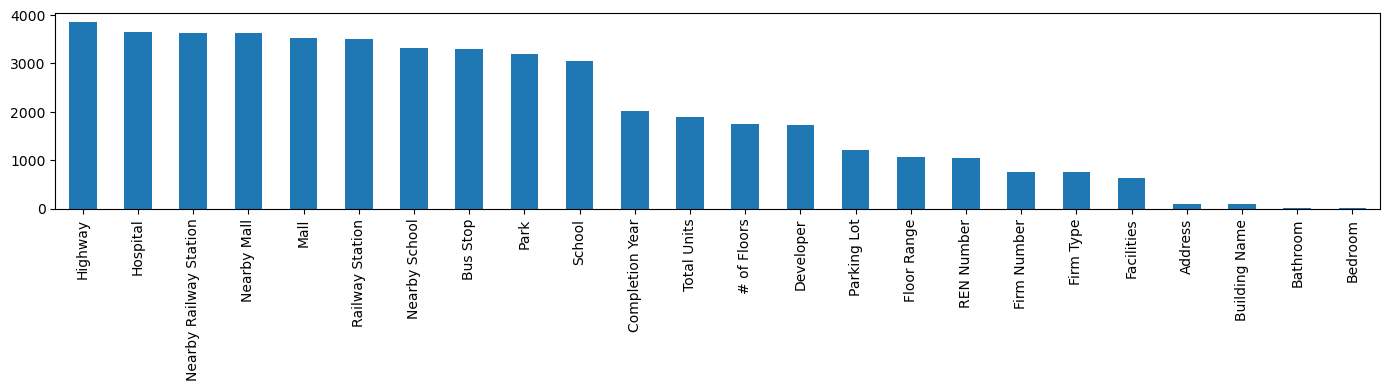

In [19]:
null_counts = df.isnull().sum() + df.apply(lambda c: (c == '-').sum() if c.dtype == 'object' else 0)
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
null_counts.plot(kind='bar', figsize=(14, 4))
plt.tight_layout()

In [20]:
df[['price', 'Property Size', 'Bedroom', 'Bathroom']].head(10)

,price,Property Size,Bedroom,Bathroom
0,RM 340 000,1000 sq.ft.,4,2
1,RM 250 000,980 sq.ft.,3,2
2,RM 230 000,1000 sq.ft.,3,2
3,RM 158 000,592 sq.ft.,3,1
4,RM 305 000,467 sq.ft.,1,1
5,RM 425 000,1100 sq.ft.,3,2
6,RM 230 000,780 sq.ft.,3,2
7,RM 200 000,852 sq.ft.,3,2
8,RM 275 000,918 sq.ft.,3,2
9,RM 300 000,850 sq.ft.,3,2


In [21]:
for col in ['Property Type', 'Tenure Type', 'Land Title', 'Category']:
    display(df[col].value_counts())

Property Type
Condominium          1714
Apartment            1494
Service Residence     506
Flat                  247
Others                 17
Studio                 13
Duplex                  5
Townhouse Condo         4
Name: count, dtype: int64

Tenure Type
Freehold     2426
Leasehold    1574
Name: count, dtype: int64

Land Title
Non Bumi Lot      3360
Bumi Lot           632
Malay Reserved       8
Name: count, dtype: int64

Category
Apartment / Condominium, For sale    4000
Name: count, dtype: int64

In [22]:
(df == '-').sum().sort_values(ascending=False).head(15)

Completion Year    2021
Total Units        1902
# of Floors        1749
Developer          1731
Parking Lot        1219
Floor Range        1062
REN Number          833
Facilities          641
Firm Number         548
Firm Type           548
Building Name        87
Address              87
Bathroom              1
Bedroom               1
Mall                  0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(185)

In [24]:
df['description'].dropna().str.len().describe()

count    4000.00000
mean      679.64350
std       407.59391
min         8.00000
25%       404.00000
50%       635.00000
75%       850.00000
max      4381.00000
Name: description, dtype: float64

In [25]:
df[['Ad List', 'Firm Number', 'REN Number', 'Firm Type']].nunique()

Ad List        3793
Firm Number     336
REN Number      963
Firm Type         8
dtype: int64

In [26]:
proximity_cols = ['Highway', 'Hospital', 'Nearby Railway Station', 'Nearby Mall',
                  'Nearby School', 'Railway Station', 'Mall', 'Bus Stop', 'Park', 'School']
(df[proximity_cols].isnull().sum() + (df[proximity_cols] == '-').sum()) / len(df) * 100

Highway                   96.475
Hospital                  91.425
Nearby Railway Station    90.925
Nearby Mall               90.875
Nearby School             82.825
Railway Station           87.875
Mall                      88.125
Bus Stop                  82.300
Park                      79.825
School                    76.300
dtype: float64

### Findings

- **price**: stored as "RM XXX XXX" string, needs stripping and numeric conversion
- **Property Size**: has "sq.ft." suffix, needs stripping
- **Bedroom/Bathroom**: string types, need numeric conversion
- **"-" placeholders**: used as null across many columns
- **Columns to drop**: Ad List, Firm Number, REN Number, Firm Type (metadata, not useful)
- **Proximity columns**: >80% nulls, drop all 10
- **description**: free text, drop for tabular analysis
- **Category**: low variance, drop
- **Derived features**: extract state from Address, compute facility_count from Facilities, derive price_per_sqft